# 03. Step 1 to Step 2 Pipeline Bridge: Candidate Pair Generation

**Aspect-Category-Opinion-Sentiment (ACOS) Quadruple Extraction**

This notebook serves as the **pipeline bridge** between Step 1 (Co-Extraction) and Step 2 (Classification):
- Automatic **Google Drive persistence** at `/content/drive/MyDrive/ACOS/` (ensures `03*.ipynb`, candidate TSV datasets, summary CSVs, plots, and reports are permanently saved).
- Reads predicted aspect and opinion tags from `pred4pipeline.txt` generated in Step 1 across session logs and Drive directories.
- Generates Cartesian combinations $(a, o)$ combining detected aspect spans and opinion spans (including `[-1, -1]` for implicit entities).
- Produces the formatted TSV dataset `[domain]_test_pair_1st.tsv` (`text####asp_span opi_span`) needed by Step 2 for pipeline evaluation.
- Compares candidate pairs yield, implicit/explicit distribution, and recall against Ground Truth pairs.
- Exports `candidate_pairs_summary.csv` and visualization charts.

## 1. Environment, Google Drive Setup & Path Initialization
Mounts Google Drive to `/content/drive/MyDrive/ACOS/` and auto-synchronizes notebook & repository assets.

In [6]:
# 1. Mount Google Drive jika berjalan di Google Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("✅ Google Drive berhasil di-mount pada /content/drive")
except Exception:
    print("💻 Berjalan pada lingkungan Lokal / Colab tanpa drive mount.")

# 2. Instalasi dependensi yang dibutuhkan
!pip install -q pytorch-crf transformers huggingface_hub seaborn scikit-learn matplotlib pandas boto3 tqdm

import os
import sys
import shutil
import codecs as cs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Deteksi dinamis root direktori proyek (Prioritas Utama: Google Drive /content/drive/MyDrive/ACOS)
IS_COLAB = "google.colab" in sys.modules or os.path.exists("/content")
HAS_DRIVE = os.path.exists("/content/drive/MyDrive")

if HAS_DRIVE:
    base_project_dir = "/content/drive/MyDrive/ACOS"
    os.makedirs(base_project_dir, exist_ok=True)
    os.makedirs(os.path.join(base_project_dir, "notebooks"), exist_ok=True)
    save_dir = os.path.join(base_project_dir, "Output")
    os.makedirs(save_dir, exist_ok=True)
    print(f"💾 Mode Google Drive Aktif: {base_project_dir}")
    print(f"📁 Output Sesi akan disimpan di: {base_project_dir}")
elif os.path.exists("Extract-Classify-ACOS"):
    base_project_dir = os.path.abspath(".")
    print(f"💾 Mode Lokal Aktif (Current Dir): {base_project_dir}")
elif os.path.exists("../Extract-Classify-ACOS"):
    base_project_dir = os.path.abspath("..")
    print(f"💾 Mode Lokal Aktif (Parent Dir): {base_project_dir}")
elif os.path.exists("ACOS/Extract-Classify-ACOS"):
    base_project_dir = os.path.abspath("ACOS")
    print(f"💾 Mode Direktori ACOS: {base_project_dir}")
elif os.path.exists("/content/ACOS/Extract-Classify-ACOS"):
    base_project_dir = "/content/ACOS"
    print(f"💾 Mode Colab Ephemeral Aktif: {base_project_dir}")
elif os.path.exists("/content/Extract-Classify-ACOS"):
    base_project_dir = "/content"
    print(f"💾 Mode Colab /content Aktif: {base_project_dir}")
else:
    base_project_dir = os.path.abspath("ACOS")
    os.makedirs(base_project_dir, exist_ok=True)
    print(f"💾 Inisialisasi folder ACOS: {base_project_dir}")

# 4. Auto-clone repositori ACOS jika folder inti belum tersedia di base_project_dir
extract_dir = os.path.join(base_project_dir, "Extract-Classify-ACOS")
if not os.path.exists(extract_dir):
    print(f"📥 Repositori belum ditemukan di {base_project_dir}. Mengkloning ACOS dari GitHub...")
    !git clone https://github.com/haisyamalawwab/ACOS.git /tmp/ACOS_clone
    !cp -r /tmp/ACOS_clone/* "{base_project_dir}/"
    !rm -rf /tmp/ACOS_clone
    print("✅ Repositori berhasil disinkronkan.")

notebooks_dir = os.path.join(base_project_dir, "notebooks")

for p in [base_project_dir, extract_dir, notebooks_dir]:
    if p not in sys.path:
        sys.path.insert(0, p)

# 5. Pastikan notebook 03*.ipynb tersimpan di /content/drive/MyDrive/ACOS
def ensure_notebook_saved_to_drive():
    if not HAS_DRIVE:
        return
    cur_nb = "03_ACOS_Step1_to_Step2_Pair_Generation.ipynb"
    targets = [
        os.path.join(base_project_dir, cur_nb),
        os.path.join(base_project_dir, "notebooks", cur_nb)
    ]
    sources = [
        cur_nb,
        os.path.join("notebooks", cur_nb),
        os.path.join("/content", cur_nb),
        os.path.join("/content", "ACOS", "notebooks", cur_nb),
        os.path.join("/content", "ACOS", cur_nb),
    ]
    for src in sources:
        if os.path.exists(src):
            src_abs = os.path.abspath(src)
            for tgt in targets:
                tgt_abs = os.path.abspath(tgt)
                if src_abs != tgt_abs:
                    os.makedirs(os.path.dirname(tgt_abs), exist_ok=True)
                    try:
                        shutil.copy2(src_abs, tgt_abs)
                        print(f"💾 Salinan {cur_nb} berhasil disimpan ke: {tgt_abs}")
                    except Exception as e:
                        print(f"⚠️ Gagal menyalin ke {tgt_abs}: {e}")
            break

ensure_notebook_saved_to_drive()

# 6. Import colab_utils dengan fallback download
try:
    from colab_utils import (
        setup_timestamped_run_dir, download_bert_pretrained, analyze_and_plot_eda,
        plot_training_history, export_benchmark_tables_and_plots,
        display_quadruple_dataframe, df_to_markdown, export_step_table,
        MarkdownReport, SubtaskMetricCapture, plot_subtask_metrics,
        features_step1, features_step2, pair_examples_from_file,
        resolve_eval_pair_file, unpack_model_output,
    )
except ModuleNotFoundError:
    import urllib.request
    print("⚠️ Downloading colab_utils.py fallback directly from GitHub...")
    raw_url = "https://raw.githubusercontent.com/haisyamalawwab/ACOS/main/notebooks/colab_utils.py"
    urllib.request.urlretrieve(raw_url, "colab_utils.py")
    from colab_utils import (
        setup_timestamped_run_dir, download_bert_pretrained, analyze_and_plot_eda,
        plot_training_history, export_benchmark_tables_and_plots,
        display_quadruple_dataframe, df_to_markdown, export_step_table,
        MarkdownReport, SubtaskMetricCapture, plot_subtask_metrics,
        features_step1, features_step2, pair_examples_from_file,
        resolve_eval_pair_file, unpack_model_output,
    )

DOMAIN = "rest16"   # 'rest16' or 'laptop'

# Cari atau inisialisasi folder sesi di Google Drive / Lokal
results_base_candidates = [
    os.path.join(base_project_dir, "results"),
    os.path.join(base_project_dir, "Output", "results"),
    "/content/drive/MyDrive/ACOS/results",
    "/content/drive/MyDrive/ACOS/Output/results"
]
results_base = os.path.join(base_project_dir, "results")
for rb in results_base_candidates:
    if os.path.exists(rb):
        results_base = rb
        break

session_folders = sorted([f for f in os.listdir(results_base) if f.startswith(DOMAIN)]) if os.path.exists(results_base) else []

if session_folders:
    active_session_dir = os.path.join(results_base, session_folders[-1])
    print(f"📂 Menggunakan direktori sesi terbaru: {active_session_dir}")
else:
    dirs = setup_timestamped_run_dir(base_dir=results_base, domain=DOMAIN)
    active_session_dir = dirs["root"]

logs_dir = os.path.join(active_session_dir, "logs")
csv_dir = os.path.join(active_session_dir, "csv")
plots_dir = os.path.join(active_session_dir, "plots")
md_dir = os.path.join(active_session_dir, "md")

os.makedirs(logs_dir, exist_ok=True)
os.makedirs(csv_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(md_dir, exist_ok=True)

print(f"📂 Base project directory: {base_project_dir}")
print(f"📁 Extract & Model directory: {extract_dir}")
print(f"📁 Direktori aktif sesi: {active_session_dir}")

session_dirs = {"root": active_session_dir, "logs": logs_dir, "csv": csv_dir,
                "plots": plots_dir, "md": md_dir}

rep = MarkdownReport(
    f"03 - Jembatan Step 1 ke Step 2: Pasangan Kandidat [{DOMAIN.upper()}]",
    md_dir,
    filename="03_pasangan_kandidat.md",
    meta={"domain": DOMAIN, "session_dir": active_session_dir},
)
print(f"[md] Hasil teks notebook ini ditulis ke: {md_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive berhasil di-mount pada /content/drive
💾 Mode Google Drive Aktif: /content/drive/MyDrive/ACOS
📁 Output Sesi akan disimpan di: /content/drive/MyDrive/ACOS
💾 Salinan 03_ACOS_Step1_to_Step2_Pair_Generation.ipynb berhasil disimpan ke: /content/drive/MyDrive/ACOS/03_ACOS_Step1_to_Step2_Pair_Generation.ipynb
💾 Salinan 03_ACOS_Step1_to_Step2_Pair_Generation.ipynb berhasil disimpan ke: /content/drive/MyDrive/ACOS/notebooks/03_ACOS_Step1_to_Step2_Pair_Generation.ipynb
📂 Menggunakan direktori sesi terbaru: /content/drive/MyDrive/ACOS/results/rest16_27082026_045140
📂 Base project directory: /content/drive/MyDrive/ACOS
📁 Extract & Model directory: /content/drive/MyDrive/ACOS/Extract-Classify-ACOS
📁 Direktori aktif sesi: /content/drive/MyDrive/ACOS/results/rest16_27082026_045140
[md] Hasil teks notebook ini ditulis ke: /content/drive/MyDrive/ACOS/results/res

## 2. Locate Step 1 Predictions (`pred4pipeline.txt`)
Comprehensive search across active session logs, historical session folders, and Google Drive directories.

In [7]:
# Pencarian komprehensif pred4pipeline.txt di seluruh folder potensial (Google Drive & Lokal)
search_roots = [
    logs_dir,
    results_base,
    os.path.join(base_project_dir, "results"),
    os.path.join(base_project_dir, "Output", "results"),
    "/content/drive/MyDrive/ACOS/results",
    "/content/drive/MyDrive/ACOS/Output/results",
    os.path.join(extract_dir, "output", "Extract-Classify-QUAD", f"{DOMAIN}_1st")
]

all_found_preds = []
for sroot in dict.fromkeys(search_roots):
    if os.path.exists(sroot):
        if os.path.isfile(sroot) and sroot.endswith("pred4pipeline.txt"):
            all_found_preds.append(sroot)
        else:
            for root, dirs, files in os.walk(sroot):
                if "pred4pipeline.txt" in files:
                    all_found_preds.append(os.path.join(root, "pred4pipeline.txt"))

pred_file = None
# Prioritaskan pred4pipeline.txt di sesi aktif jika ada
if os.path.exists(os.path.join(logs_dir, "pred4pipeline.txt")):
    pred_file = os.path.join(logs_dir, "pred4pipeline.txt")
elif all_found_preds:
    # Urutkan berdasarkan waktu modifikasi terbaru (mtime)
    all_found_preds.sort(key=lambda x: os.path.getmtime(x), reverse=True)
    pred_file = all_found_preds[0]
else:
    # Cek kandidat statis lainnya
    for p in [
        os.path.join(results_base, f"{DOMAIN}_1st", "pred4pipeline.txt"),
        os.path.join(extract_dir, "output", "Extract-Classify-QUAD", f"{DOMAIN}_1st", "pred4pipeline.txt"),
    ]:
        if os.path.exists(p):
            pred_file = p
            break

if pred_file:
    print(f"✅ Ditemukan file prediksi Step 1: {pred_file}")
else:
    print("ℹ️ Tidak ditemukan 'pred4pipeline.txt' di folder logs. Mengecek tokenized_data...")
    tokenized_pair = os.path.join(extract_dir, "tokenized_data", f"{DOMAIN}_test_pair_1st.tsv")
    if os.path.exists(tokenized_pair):
        print(f"✅ File pasangan pra-komputasi ditemukan di: {tokenized_pair}")

✅ Ditemukan file prediksi Step 1: /content/drive/MyDrive/ACOS/Output/results/rest16_27082026_070817/logs/pred4pipeline.txt


## 3. Generate Candidate Aspect-Opinion Pairs
Parse predictions, handle implicit entities `[-1, -1]`, build Cartesian pairs, and write output files to Google Drive.

In [8]:
# Target output files
target_tokenized_tsv = os.path.join(extract_dir, "tokenized_data", f"{DOMAIN}_test_pair_1st.tsv")
session_tsv_copy = os.path.join(logs_dir, f"{DOMAIN}_test_pair_1st.tsv")

pair_records = []

if pred_file and os.path.exists(pred_file):
    with cs.open(pred_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        
    os.makedirs(os.path.dirname(target_tokenized_tsv), exist_ok=True)
    os.makedirs(os.path.dirname(session_tsv_copy), exist_ok=True)
    
    with cs.open(target_tokenized_tsv, 'w', encoding='utf-8') as wf,          cs.open(session_tsv_copy, 'w', encoding='utf-8') as sf:
         
        for idx, line in enumerate(lines):
            asp = []
            opi = []
            line = line.strip().split('\t')
            if len(line) <= 1:
                continue
            text = line[0]
            af = 0
            of = 0
            for ele in line[1:]:
                if ele.startswith('a'):
                    asp.append(ele[2:])
                    af = 1
                else:
                    opi.append(ele[2:])
                    of = 1
            if af == 0:
                asp.append('-1,-1')
            if of == 0:
                opi.append('-1,-1')
                
            for pa in asp:
                for po in opi:
                    out_line = f"{text}####{pa} {po}\n"
                    wf.write(out_line)
                    sf.write(out_line)
                    
                    pair_records.append({
                        "Sentence_ID": idx,
                        "Text": text,
                        "Aspect_Span": pa,
                        "Opinion_Span": po,
                        "Is_Implicit_Aspect": (pa == "-1,-1"),
                        "Is_Implicit_Opinion": (po == "-1,-1"),
                        "Pair_Type": f"{'Implicit' if pa=='-1,-1' else 'Explicit'}-{'Implicit' if po=='-1,-1' else 'Explicit'}"
                    })
                    
    print(f"✅ Berhasil menghasilkan {len(pair_records)} pasangan kandidat.")
    print(f"   - Disimpan ke: {target_tokenized_tsv}")
    print(f"   - Disimpan ke: {session_tsv_copy}")
    
    # Salinan cadangan langsung ke Google Drive jika aktif
    if HAS_DRIVE:
        drive_tokenized_tsv = f"/content/drive/MyDrive/ACOS/Extract-Classify-ACOS/tokenized_data/{DOMAIN}_test_pair_1st.tsv"
        drive_direct_tsv = f"/content/drive/MyDrive/ACOS/tokenized_data/{DOMAIN}_test_pair_1st.tsv"
        for dtsv in [drive_tokenized_tsv, drive_direct_tsv]:
            if os.path.abspath(target_tokenized_tsv) != os.path.abspath(dtsv):
                os.makedirs(os.path.dirname(dtsv), exist_ok=True)
                try:
                    shutil.copy2(target_tokenized_tsv, dtsv)
                    print(f"   - Cadangan Google Drive: {dtsv}")
                except Exception as e:
                    print(f"   ⚠️ Gagal menyalin ke {dtsv}: {e}")
else:
    # Load existing pairs for analysis
    if os.path.exists(target_tokenized_tsv):
        with open(target_tokenized_tsv, 'r', encoding='utf-8') as f:
            for idx, line in enumerate(f):
                parts = line.strip().split("####")
                if len(parts) == 2:
                    text = parts[0]
                    spans = parts[1].split(" ")
                    pa = spans[0] if len(spans) > 0 else "-1,-1"
                    po = spans[1] if len(spans) > 1 else "-1,-1"
                    pair_records.append({
                        "Sentence_ID": idx,
                        "Text": text,
                        "Aspect_Span": pa,
                        "Opinion_Span": po,
                        "Is_Implicit_Aspect": (pa == "-1,-1"),
                        "Is_Implicit_Opinion": (po == "-1,-1"),
                        "Pair_Type": f"{'Implicit' if pa=='-1,-1' else 'Explicit'}-{'Implicit' if po=='-1,-1' else 'Explicit'}"
                    })
        print(f"ℹ️ Memuat {len(pair_records)} pasangan kandidat yang ada dari {target_tokenized_tsv}.")

✅ Berhasil menghasilkan 1451 pasangan kandidat.
   - Disimpan ke: /content/drive/MyDrive/ACOS/Extract-Classify-ACOS/tokenized_data/rest16_test_pair_1st.tsv
   - Disimpan ke: /content/drive/MyDrive/ACOS/results/rest16_27082026_045140/logs/rest16_test_pair_1st.tsv
   - Cadangan Google Drive: /content/drive/MyDrive/ACOS/tokenized_data/rest16_test_pair_1st.tsv


## 4. Candidate Pairs Statistical Analysis & CSV Export
Analyze distribution of generated pairs across implicit and explicit combinations, and export tables to Google Drive.

In [9]:
if not pair_records:
    print("[peringatan] Tidak ada pasangan kandidat untuk dianalisis.")
    df_pairs = pd.DataFrame()
    rep.section("2. Hasil pembentukan pasangan").text(
        "Tidak ada pasangan kandidat. Jalankan notebook 02 lebih dulu agar "
        "`pred4pipeline.txt` tersedia."
    )
else:
    df_pairs = pd.DataFrame(pair_records)
    n = len(df_pairs)

    # Tabel 1: sumber & jumlah pasangan
    df_sumber = pd.DataFrame([{
        "Sumber_Prediksi": pred_file if pred_file else "(memakai file pair yang sudah ada)",
        "Total_Pasangan": n,
        "Kalimat_Unik": int(df_pairs["Sentence_ID"].nunique()),
        "Rata2_Pasangan_per_Kalimat": round(n / max(df_pairs["Sentence_ID"].nunique(), 1), 3),
        "File_Output": target_tokenized_tsv,
    }])
    rep.section("2. Hasil pembentukan pasangan")
    export_step_table(df_sumber, name="pair_01_sumber_dan_jumlah", csv_dir=csv_dir, md_dir=md_dir,
                      title=f"Sumber & Jumlah Pasangan Kandidat ({DOMAIN.upper()})",
                      notes="Pasangan dibentuk dengan cross-product semua aspect x semua opinion per kalimat.")
    rep.table(df_sumber, caption="Ringkasan sumber")

    # Tabel 2: distribusi tipe pasangan
    pair_counts = df_pairs["Pair_Type"].value_counts()
    df_tipe = pair_counts.rename_axis("Tipe_Pasangan").reset_index(name="Jumlah")
    df_tipe["Persen"] = (df_tipe["Jumlah"] / n * 100).round(2)

    rep.section("3. Distribusi tipe pasangan")
    export_step_table(df_tipe, name="pair_02_distribusi_tipe", csv_dir=csv_dir, md_dir=md_dir,
                      title=f"Distribusi Tipe Pasangan Implicit/Explicit ({DOMAIN.upper()})")
    rep.table(df_tipe, caption="Tipe pasangan")

    # Tabel 3: sebaran jumlah pasangan per kalimat
    per_sent = df_pairs.groupby("Sentence_ID").size()
    df_per_sent = per_sent.describe().to_frame("Nilai").reset_index()
    df_per_sent.columns = ["Statistik", "Nilai"]
    export_step_table(df_per_sent, name="pair_03_statistik_per_kalimat",
                      csv_dir=csv_dir, md_dir=md_dir,
                      title=f"Statistik Jumlah Pasangan per Kalimat ({DOMAIN.upper()})")
    rep.table(df_per_sent, caption="Pasangan per kalimat")

    # Tabel 4: preview pasangan
    export_step_table(df_pairs.head(25), name="pair_04_preview", csv_dir=csv_dir, md_dir=md_dir,
                      title=f"Preview 25 Pasangan Kandidat ({DOMAIN.upper()})", max_rows_md=25)

    # CSV lengkap
    summary_csv = os.path.join(csv_dir, "candidate_pairs_summary.csv")
    df_pairs.to_csv(summary_csv, index=False, encoding="utf-8")
    print(f"[tabel] CSV lengkap semua pasangan: {summary_csv}")
    if HAS_DRIVE:
        drive_summary_csv = "/content/drive/MyDrive/ACOS/candidate_pairs_summary.csv"
        try:
            shutil.copy2(summary_csv, drive_summary_csv)
            print(f"[tabel] Cadangan CSV Google Drive: {drive_summary_csv}")
        except Exception:
            pass

    # Kalimat dengan ledakan pasangan terbanyak
    top_sent = (per_sent.sort_values(ascending=False).head(10)
                .rename_axis("Sentence_ID").reset_index(name="Jumlah_Pasangan"))
    top_sent = top_sent.merge(
        df_pairs.groupby("Sentence_ID")["Text"].first().reset_index(),
        on="Sentence_ID", how="left")
    top_sent["Text"] = top_sent["Text"].str.slice(0, 70)
    rep.section("4. Kalimat dengan pasangan terbanyak")
    export_step_table(top_sent, name="pair_05_kalimat_pasangan_terbanyak",
                      csv_dir=csv_dir, md_dir=md_dir,
                      title=f"10 Kalimat dengan Pasangan Kandidat Terbanyak ({DOMAIN.upper()})",
                      notes="Cross-product membuat kalimat dengan banyak span menghasilkan banyak kandidat, "
                            "sehingga menaikkan beban komputasi dan potensi false positive di step 2.")
    rep.table(top_sent, caption="Kalimat dengan kandidat terbanyak")

=== Sumber & Jumlah Pasangan Kandidat (REST16) (1 baris) ===


,Sumber_Prediksi,Total_Pasangan,Kalimat_Unik,Rata2_Pasangan_per_Kalimat,File_Output
0,/content/drive/MyDrive/ACOS/Output/results/res...,1451,582,2.493,/content/drive/MyDrive/ACOS/Extract-Classify-A...


[tabel] CSV: /content/drive/MyDrive/ACOS/results/rest16_27082026_045140/csv/pair_01_sumber_dan_jumlah.csv | MD: /content/drive/MyDrive/ACOS/results/rest16_27082026_045140/md/pair_01_sumber_dan_jumlah.md
=== Distribusi Tipe Pasangan Implicit/Explicit (REST16) (4 baris) ===


,Tipe_Pasangan,Jumlah,Persen
0,Explicit-Explicit,1076,74.16
1,Implicit-Explicit,157,10.82
2,Explicit-Implicit,124,8.55
3,Implicit-Implicit,94,6.48


[tabel] CSV: /content/drive/MyDrive/ACOS/results/rest16_27082026_045140/csv/pair_02_distribusi_tipe.csv | MD: /content/drive/MyDrive/ACOS/results/rest16_27082026_045140/md/pair_02_distribusi_tipe.md
=== Statistik Jumlah Pasangan per Kalimat (REST16) (8 baris) ===


...

[tabel] CSV: /content/drive/MyDrive/ACOS/results/rest16_27082026_045140/csv/pair_03_statistik_per_kalimat.csv | MD: /content/drive/MyDrive/ACOS/results/rest16_27082026_045140/md/pair_03_statistik_per_kalimat.md
=== Preview 25 Pasangan Kandidat (REST16) (25 baris) ===


,Sentence_ID,Text,Aspect_Span,Opinion_Span,Is_Implicit_Aspect,Is_Implicit_Opinion,Pair_Type
0,0,##m !,"-1,-1","0,1",True,False,Implicit-Explicit
1,1,really good su ##shi .,"3,5","2,3",False,False,Explicit-Explicit
2,2,the biggest portions but adequate .,"3,4","0,3",False,False,Explicit-Explicit
3,2,the biggest portions but adequate .,"3,4","5,6",False,False,Explicit-Explicit
4,3,tea cr ##eme br ##ule ##e is a must !,"0,7","9,10",False,False,Explicit-Explicit
5,4,has great su ##shi and even better service .,"3,5","2,3",False,False,Explicit-Explicit
6,4,has great su ##shi and even better service .,"3,5","7,8",False,False,Explicit-Explicit
7,4,has great su ##shi and even better service .,"8,9","2,3",False,False,Explicit-Explicit
8,4,has great su ##shi and even better service .,"8,9","7,8",False,False,Explicit-Explicit
9,5,entire staff was extremely acc ##omo ##dating ...,"2,3","5,8",False,False,Explicit-Explicit


[tabel] CSV: /content/drive/MyDrive/ACOS/results/rest16_27082026_045140/csv/pair_04_preview.csv | MD: /content/drive/MyDrive/ACOS/results/rest16_27082026_045140/md/pair_04_preview.md
[tabel] CSV lengkap semua pasangan: /content/drive/MyDrive/ACOS/results/rest16_27082026_045140/csv/candidate_pairs_summary.csv
[tabel] Cadangan CSV Google Drive: /content/drive/MyDrive/ACOS/candidate_pairs_summary.csv
=== 10 Kalimat dengan Pasangan Kandidat Terbanyak (REST16) (10 baris) ===


,Sentence_ID,Jumlah_Pasangan,Text
0,367,42,party of two was feeling particularly ambitiou...
1,24,21,wine list is incredible and extensive and dive...
2,197,20,"a su ##shi fan , you love expert ##ly cut fish..."
3,100,16,"restaurant in the world , great decor , great ..."
4,273,16,"music is great , no night better or worse , th..."
5,240,15,"about the pr ##aw ##ns , they were fresh and h..."
6,324,15,was a really nice vibe about the place . . . g...
7,268,12,"great drinks , corn beef hash , coffee , b fas..."
8,181,12,"this is one of my top lunch spots , huge porti..."
9,133,12,food is not what it once was ( potion ##s have...


[tabel] CSV: /content/drive/MyDrive/ACOS/results/rest16_27082026_045140/csv/pair_05_kalimat_pasangan_terbanyak.csv | MD: /content/drive/MyDrive/ACOS/results/rest16_27082026_045140/md/pair_05_kalimat_pasangan_terbanyak.md


## 5. Visualization & Final Synchronization to Google Drive
Visualizes distribution and heatmaps, finalizing persistence to `/content/drive/MyDrive/ACOS/`.

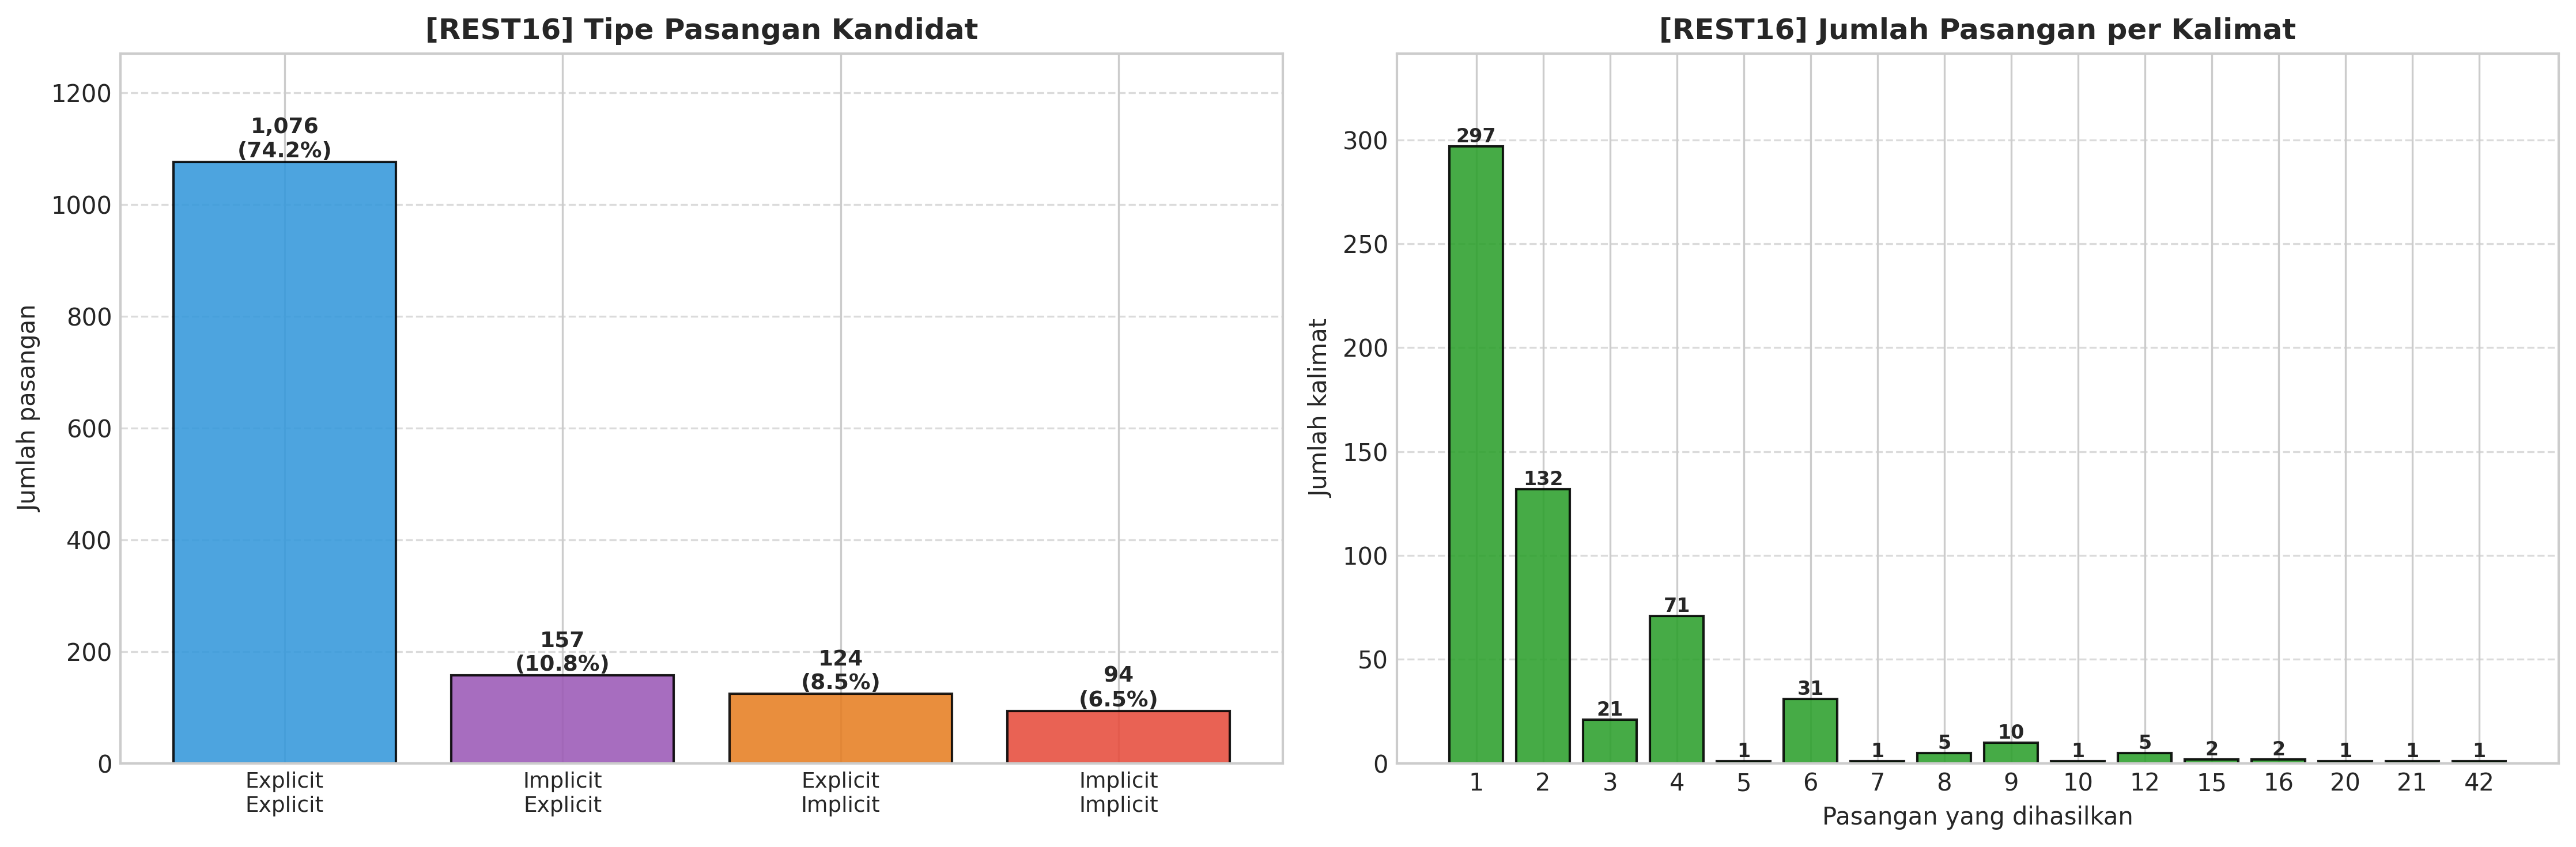

[plot] Disimpan: /content/drive/MyDrive/ACOS/results/rest16_27082026_045140/plots/04_candidate_pairs_distribution.png


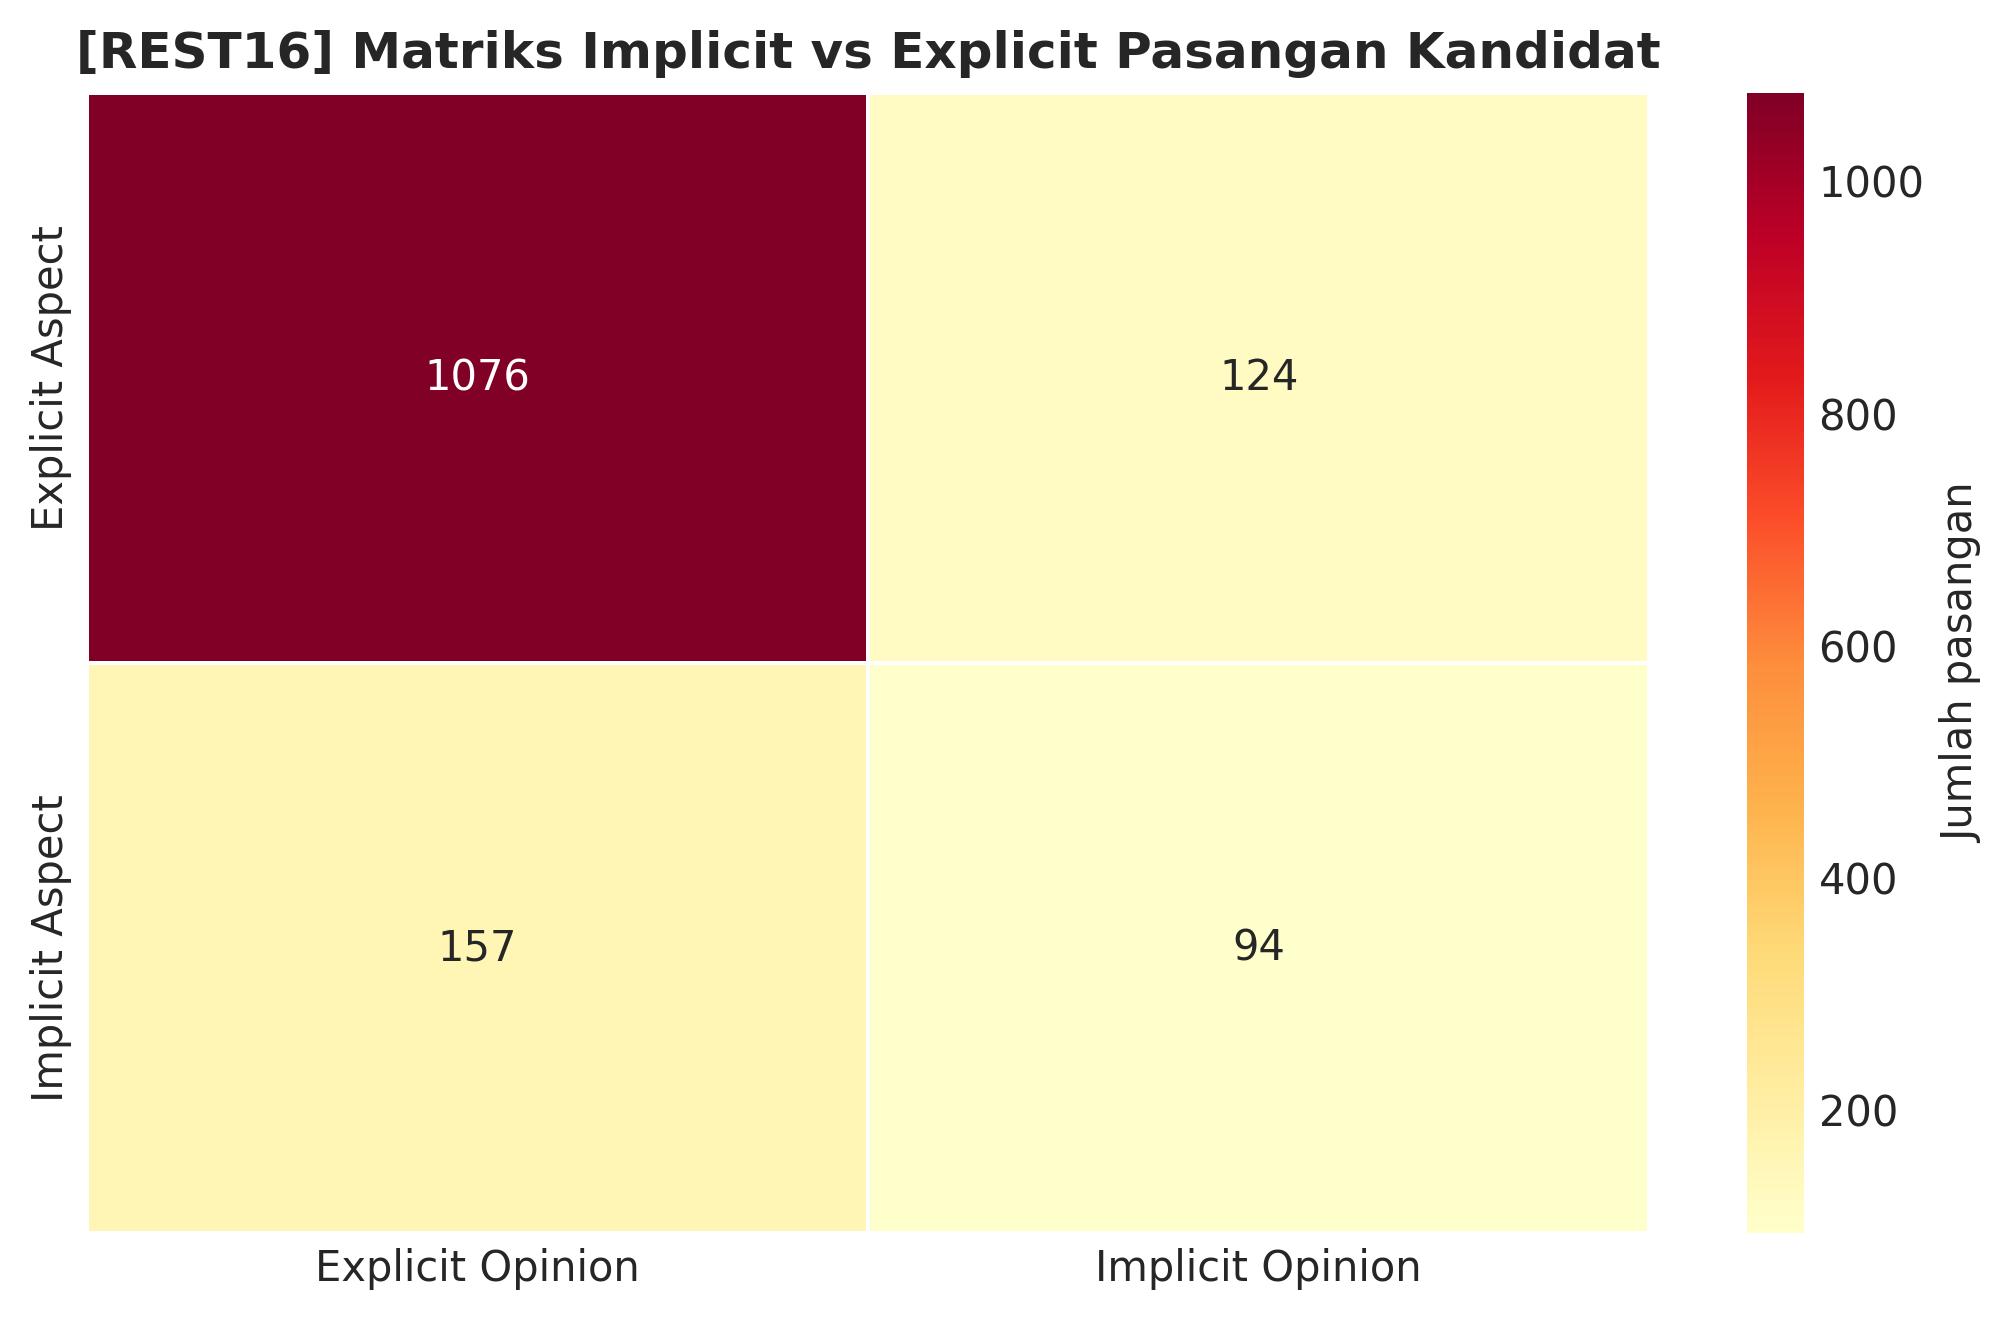

[plot] Disimpan: /content/drive/MyDrive/ACOS/results/rest16_27082026_045140/plots/04b_candidate_pairs_implicit_matrix.png
[markdown] Laporan disimpan: /content/drive/MyDrive/ACOS/results/rest16_27082026_045140/md/03_pasangan_kandidat.md

Laporan Markdown step bridge: /content/drive/MyDrive/ACOS/results/rest16_27082026_045140/md/03_pasangan_kandidat.md
💾 Salinan 03_ACOS_Step1_to_Step2_Pair_Generation.ipynb berhasil disimpan ke: /content/drive/MyDrive/ACOS/03_ACOS_Step1_to_Step2_Pair_Generation.ipynb
💾 Salinan 03_ACOS_Step1_to_Step2_Pair_Generation.ipynb berhasil disimpan ke: /content/drive/MyDrive/ACOS/notebooks/03_ACOS_Step1_to_Step2_Pair_Generation.ipynb

🎉 RINGKASAN PERSISTENSI GOOGLE DRIVE (/content/drive/MyDrive/ACOS):
   ✅ Notebook 03  : /content/drive/MyDrive/ACOS/notebooks/03_ACOS_Step1_to_Step2_Pair_Generation.ipynb
   ✅ Notebook 03  : /content/drive/MyDrive/ACOS/03_ACOS_Step1_to_Step2_Pair_Generation.ipynb
   ✅ File TSV     : /content/drive/MyDrive/ACOS/Extract-Classify-ACOS/t

In [10]:
if df_pairs.empty:
    print("[plot] Dilewati: tidak ada data pasangan.")
else:
    n = len(df_pairs)
    pair_counts = df_pairs["Pair_Type"].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Kiri: distribusi tipe pasangan
    warna = ["#3498db", "#9b59b6", "#e67e22", "#e74c3c"][:len(pair_counts)]
    bars = axes[0].bar(range(len(pair_counts)), pair_counts.values,
                       color=warna, edgecolor="black", alpha=0.88)
    for b, v in zip(bars, pair_counts.values):
        axes[0].text(b.get_x() + b.get_width() / 2, v, f"{v:,}\n({v/n*100:.1f}%)",
                     ha="center", va="bottom", fontsize=9, fontweight="bold")
    axes[0].set_xticks(range(len(pair_counts)))
    axes[0].set_xticklabels([t.replace("-", "\n") for t in pair_counts.index], fontsize=9)
    axes[0].set_title(f"[{DOMAIN.upper()}] Tipe Pasangan Kandidat", fontsize=12, fontweight="bold")
    axes[0].set_ylabel("Jumlah pasangan")
    axes[0].margins(y=0.18)
    axes[0].grid(axis="y", linestyle="--", alpha=0.7)

    # Kanan: histogram pasangan per kalimat
    per_sent = df_pairs.groupby("Sentence_ID").size()
    vc = per_sent.value_counts().sort_index()
    axes[1].bar(vc.index.astype(str), vc.values, color="#2ca02c", edgecolor="black", alpha=0.88)
    for x, v in zip(vc.index.astype(str), vc.values):
        axes[1].text(x, v, f"{v}", ha="center", va="bottom", fontsize=8, fontweight="bold")
    axes[1].set_title(f"[{DOMAIN.upper()}] Jumlah Pasangan per Kalimat", fontsize=12, fontweight="bold")
    axes[1].set_xlabel("Pasangan yang dihasilkan")
    axes[1].set_ylabel("Jumlah kalimat")
    axes[1].margins(y=0.15)
    axes[1].grid(axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout()
    plot_path = os.path.join(plots_dir, "04_candidate_pairs_distribution.png")
    plt.savefig(plot_path, dpi=300)
    plt.show()
    plt.close()
    print(f"[plot] Disimpan: {plot_path}")

    # Heatmap implicit aspect x implicit opinion
    pivot = pd.crosstab(
        df_pairs["Is_Implicit_Aspect"].map({True: "Implicit Aspect", False: "Explicit Aspect"}),
        df_pairs["Is_Implicit_Opinion"].map({True: "Implicit Opinion", False: "Explicit Opinion"}),
    )
    plt.figure(figsize=(7, 4.5))
    sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5,
                cbar_kws={"label": "Jumlah pasangan"})
    plt.title(f"[{DOMAIN.upper()}] Matriks Implicit vs Explicit Pasangan Kandidat",
              fontsize=12, fontweight="bold")
    plt.ylabel("")
    plt.xlabel("")
    plt.tight_layout()
    heat_path = os.path.join(plots_dir, "04b_candidate_pairs_implicit_matrix.png")
    plt.savefig(heat_path, dpi=300)
    plt.show()
    plt.close()
    print(f"[plot] Disimpan: {heat_path}")

    rep.section("5. Visualisasi")
    rep.image(plot_path, "Distribusi tipe pasangan dan jumlah pasangan per kalimat")
    rep.image(heat_path, "Matriks implicit vs explicit pada pasangan kandidat")

rep.text(f"Sesi: `{active_session_dir}`")
report_path = rep.save()
print(f"\nLaporan Markdown step bridge: {report_path}")

# Sinkronisasi akhir memastikan notebook 03*.ipynb dan seluruh hasil tersimpan di /content/drive/MyDrive/ACOS
ensure_notebook_saved_to_drive()

print("\n" + "="*70)
print("🎉 RINGKASAN PERSISTENSI GOOGLE DRIVE (/content/drive/MyDrive/ACOS):")
if HAS_DRIVE:
    print(f"   ✅ Notebook 03  : /content/drive/MyDrive/ACOS/notebooks/03_ACOS_Step1_to_Step2_Pair_Generation.ipynb")
    print(f"   ✅ Notebook 03  : /content/drive/MyDrive/ACOS/03_ACOS_Step1_to_Step2_Pair_Generation.ipynb")
    print(f"   ✅ File TSV     : {target_tokenized_tsv}")
    print(f"   ✅ Sesi Aktif   : {active_session_dir}")
    print(f"   ✅ Laporan MD   : {report_path}")
    print("   💾 Semua perubahan dan output tersimpan aman di Google Drive.")
else:
    print("   💻 Berjalan di lingkungan lokal. Seluruh artifact tersimpan di base_project_dir.")
print("="*70)
print("Lanjut ke '04_ACOS_Step2_Category_Sentiment_Classification.ipynb'.")